# Machine Learning Project - Bank Customer Churn Prediction

The purpose of the project is to use supervised ML models to identify customers who are likely to churn in the future using the bank data.
The data set was retrieved from [Kaggle-Predicting Churn for Bank Customer](https://www.kaggle.com/datasets/adammaus/predicting-churn-for-bank-customers)

We care about customer churn because retention is cheaper than acquisition. Therefore, if we could predict potential customer churn in the future, we may take actions/retention strategies to prevent churn.

---
## Step 0 - Loading data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
churn_df = pd.read_csv('bank.data.csv')
churn_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## Step 1 - Exploratory Data Analysis
### 1.1 Understanding the raw dataset
- How to define "customer churn"? E.g., customer close account, customer stop transactions, or customer doesn't log in for a specific timeframe?
- Check if raw data includes features that are relevant to the business problem.

In [2]:
churn_df.info()
# The dataset include 10000 entries.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


From the dataset above, `Exited` is the target variable, which indicates customer churn or not.

In [3]:
y = churn_df['Exited']

We need to check the distribution of the target variable in order to identify __imbalance__. Any situation where one class if much rarer than the other would require special care because imbalance makes accuracy misleading and pushes us to use either _another performance metric_ or _another resampling and class weighting method_.

In [4]:
# Check the distribution of target variable
print(y.value_counts(normalize = True))

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [5]:
# check unique values of variables
churn_df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

### 1.2 Understand the features

In [6]:
# Check missing values
churn_df.isnull().sum()
# No missing values in this case

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Understand the distribution of numeric features (discrete/continuous)

In [7]:
num_var = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
churn_df[num_var].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


Understand the distribution of categorical variable (Frequenct table)

In [8]:
# Get the unique values of all categorical features
cat_var = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
for col in cat_var:
    print(f"\n{col} classes:")
    print(churn_df[col].unique())


Geography classes:
['France' 'Spain' 'Germany']

Gender classes:
['Female' 'Male']

HasCrCard classes:
[1 0]

IsActiveMember classes:
[1 0]


In [9]:
# Get percentage of each class
for col in cat_var:
    print(f"\n{col} percentage:")
    print(churn_df[col].value_counts()/churn_df.shape[0] * 100)


Geography percentage:
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: count, dtype: float64

Gender percentage:
Gender
Male      54.57
Female    45.43
Name: count, dtype: float64

HasCrCard percentage:
HasCrCard
1    70.55
0    29.45
Name: count, dtype: float64

IsActiveMember percentage:
IsActiveMember
1    51.51
0    48.49
Name: count, dtype: float64


#### Visualizations (Boxplots and Bar charts)
Visualize the target variable `Exited` by numeric/categorical features

Insights:
- Age is a strong signal, older customers are more likely to churn.
- Customers with higher balances may feel underserved and could be at greater churn risk.

<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

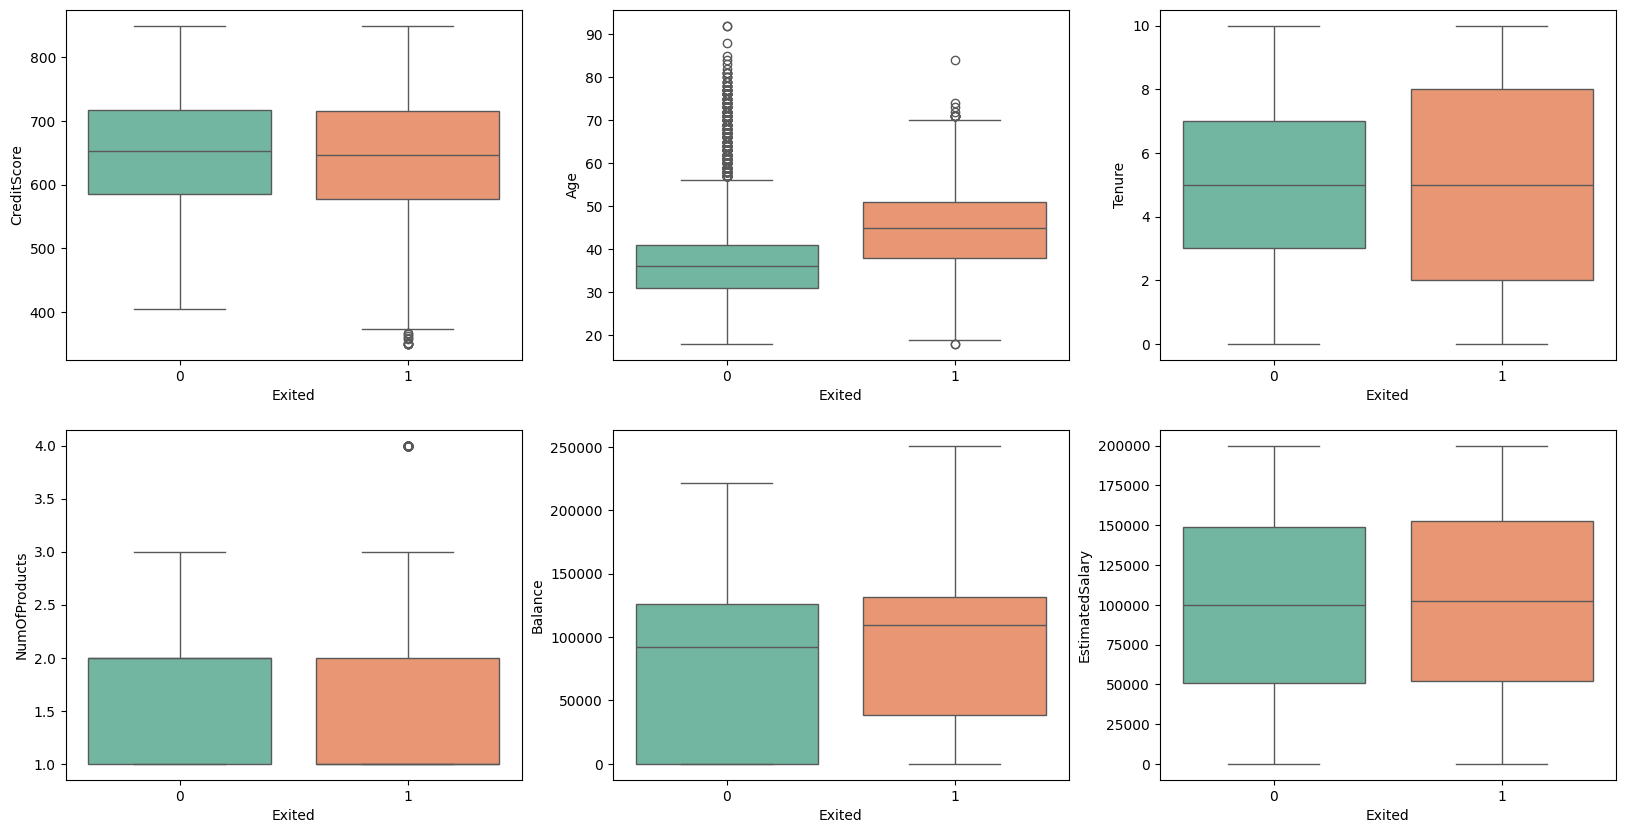

In [10]:
# numeric features
_,axss = plt.subplots(2,3, figsize=[20,10])
sns.boxplot(x='Exited', y ='CreditScore', data=churn_df, ax=axss[0][0], hue = "Exited", palette = "Set2", legend = False)
sns.boxplot(x='Exited', y ='Age', data=churn_df, ax=axss[0][1], hue = "Exited", palette = "Set2", legend = False)
sns.boxplot(x='Exited', y ='Tenure', data=churn_df, ax=axss[0][2], hue = "Exited", palette = "Set2", legend = False)
sns.boxplot(x='Exited', y ='NumOfProducts', data=churn_df, ax=axss[1][0], hue = "Exited", palette = "Set2", legend = False)
sns.boxplot(x='Exited', y ='Balance', data=churn_df, ax=axss[1][1], hue = "Exited", palette = "Set2", legend = False)
sns.boxplot(x='Exited', y ='EstimatedSalary', data=churn_df, ax=axss[1][2], hue = "Exited", palette = "Set2", legend = False)

<Axes: xlabel='Exited', ylabel='count'>

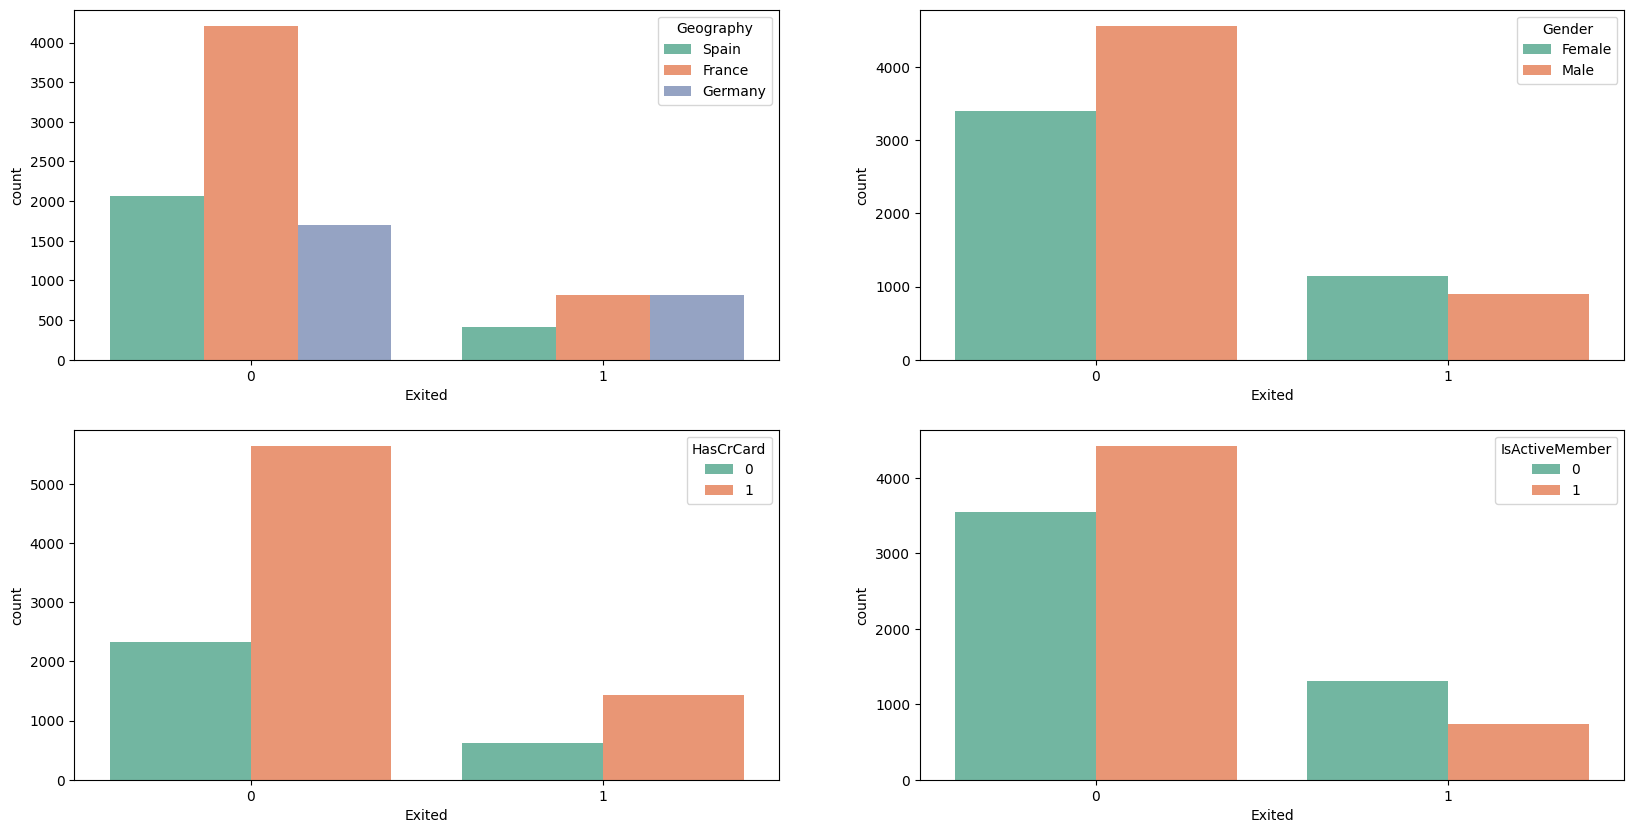

In [11]:
# categorical features
# We should pay attention to features with the frequencies of classes varied significantly between exited and not exited, like Geography, gender, and isactivemember.
_,axss = plt.subplots(2,2, figsize=[20,10])
sns.countplot(x='Exited', hue='Geography', data=churn_df, ax=axss[0][0], palette = "Set2")
sns.countplot(x='Exited', hue='Gender', data=churn_df, ax=axss[0][1], palette = "Set2")
sns.countplot(x='Exited', hue='HasCrCard', data=churn_df, ax=axss[1][0], palette = "Set2")
sns.countplot(x='Exited', hue='IsActiveMember', data=churn_df, ax=axss[1][1], palette = "Set2")

---
## Step 2 - Feature Preprocessing
1. Data inspection
2. Clean missing data and outliers
3. Transformation (encoding, scaling, normalization, feature engineering)

#### Feature preprocessing is needed because it:
- Ensure **Data Quality**, otherwise models may misinterpret noise and lead to poor accuracy.
- Make feature information **readable**, since algorithms cannot directly understand text labels or cat variables
- **Normalize Feature Scales**, ensuring fair contribution of all features
- **Improve Model Performance & Convergence**
    - Some models assume normality or linearity in features.
    - Transformations (log, Box-Cox, polynomial features) help models learn patterns faster and more accurately.
    - Standardization helps gradient descent converge more efficiently.

In [12]:
# Get features of interest by dropping some inrelevant features
to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Exited']
X = churn_df.drop(to_drop, axis = 1)

In [13]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [14]:
X.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [15]:
# separate numeric and categorical features (Why we need this step?)
cat_cols = X.columns[X.dtypes == 'object']
num_cols = X.columns[(X.dtypes == 'int64') | (X.dtypes == 'float64')]

In [16]:
num_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [17]:
cat_cols

Index(['Geography', 'Gender'], dtype='object')

### Split dataset

Approaches for dealing with imbalanced targets
- **Stratified** train/test splits
- **Cost-sensitive learning** (class weights): give higher cost to the minority class.
- **Resampling** (need to be further explored)
- **Ensembles designed for imbalance**

In [18]:
# Split data into training and testing set
from sklearn import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 1) # stratified sampling

print('training data has ' + str(X_train.shape[0]) + ' observation with ' + str(X_train.shape[1]) + ' features')
print('test data has ' + str(X_test.shape[0]) + ' observation with ' + str(X_test.shape[1]) + ' features')

training data has 7500 observation with 10 features
test data has 2500 observation with 10 features


In [19]:
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7971,633,Spain,Male,42,10,0.00,1,0,1,79408.17
9152,708,Germany,Female,23,4,71433.08,1,1,0,103697.57
6732,548,France,Female,37,9,0.00,2,0,0,98029.58
902,645,France,Female,48,7,90612.34,1,1,1,149139.13
2996,729,Spain,Female,45,7,91091.06,2,1,0,71133.12


### Handlinng Categorical Features
#### 1. Common Encoding Methods
##### One-Hot Encoding
- Creates a new binary column for each category
- For *nominal* categories
- Increases dimensionality if many categories

In [20]:
from sklearn.preprocessing import OneHotEncoder

def OneHotEncoding(df, enc, categories):
    transformed = pd.DataFrame(enc.transform(df[categories]).toarray(), columns = enc.get_feature_names_out(categories))
    return pd.concat([df.reset_index(drop = True), transformed], axis = 1).drop(categories, axis = 1)

categories = ['Geography']
enc_ohe = OneHotEncoder()
enc_ohe.fit(X_train[categories])

X_train = OneHotEncoding(X_train, enc_ohe, categories)
X_test = OneHotEncoding(X_test, enc_ohe, categories)

In [21]:
X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,633,Male,42,10,0.00,1,0,1,79408.17,0.0,0.0,1.0
1,708,Female,23,4,71433.08,1,1,0,103697.57,0.0,1.0,0.0
2,548,Female,37,9,0.00,2,0,0,98029.58,1.0,0.0,0.0
3,645,Female,48,7,90612.34,1,1,1,149139.13,1.0,0.0,0.0
4,729,Female,45,7,91091.06,2,1,0,71133.12,0.0,0.0,1.0


##### Ordinal Encoding
- Assigns integer values to categories
- For *Ordinal* categories
- If applied to *Nominal* data, introduced artificial order that can mislead the model.

In [22]:
from sklearn.preprocessing import OrdinalEncoder

categories = ['Gender']
enc_oe = OrdinalEncoder()
enc_oe.fit(X_train[categories])

X_train[categories] = enc_oe.transform(X_train[categories])
X_test[categories] = enc_oe.transform(X_test[categories])

In [23]:
X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,633,1.0,42,10,0.00,1,0,1,79408.17,0.0,0.0,1.0
1,708,0.0,23,4,71433.08,1,1,0,103697.57,0.0,1.0,0.0
2,548,0.0,37,9,0.00,2,0,0,98029.58,1.0,0.0,0.0
3,645,0.0,48,7,90612.34,1,1,1,149139.13,1.0,0.0,0.0
4,729,0.0,45,7,91091.06,2,1,0,71133.12,0.0,0.0,1.0


### Handling Numeric Features
#### Standardize/Normalize Data

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [25]:
X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-0.172985,1.0,0.289202,1.731199,-1.218916,-0.912769,-1.542199,0.968496,-0.352044,0.0,0.0,1.0
1,0.602407,0.0,-1.509319,-0.341156,-0.076977,-0.912769,0.648425,-1.032529,0.072315,0.0,1.0,0.0
2,-1.051762,0.0,-0.184093,1.385806,-1.218916,0.796109,-1.542199,-1.032529,-0.026711,1.0,0.0,0.0
3,-0.048922,0.0,0.857156,0.695022,0.229625,-0.912769,0.648425,0.968496,0.866221,1.0,0.0,0.0
4,0.819517,0.0,0.573179,0.695022,0.237278,0.796109,0.648425,-1.032529,-0.496617,0.0,0.0,1.0


---
## Step 3 - Model Training and Result Evaluation
### Step 3.1. Model Training
#### Build Models

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
classifier_logistic = LogisticRegression()

# K Nearest Neighbors
classifier_KNN = KNeighborsClassifier()

# Random Forest
classifier_RF = RandomForestClassifier()

#### Train Models

In [27]:
# Logistic Regression
classifier_logistic.fit(X_train, y_train) # default l2 penalty

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
# predict the test data
classifier_logistic.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [29]:
# accuracy of the test data
classifier_logistic.score(X_test, y_test)

0.808

#### Step 3.2. Find Optimal Hyperparameters
- **Goal**: find the hyperparameters that maximize a chosen validation metric
- **How**: try candidate settings, evaluate with cross-validation on the training data, pick the best, then retrain on full training data and finally test once on the holdout test set.

In [30]:
from sklearn.model_selection import GridSearchCV

# helper function for printing out grid search results
def print_grid_search_metrics(gs):
    print('Best score: ' + str(gs.best_score_)) # GridSearchCV attribute best_score_
    print('Best parameters set:')
    best_parameters = gs.best_params_
    for param_name in sorted(best_parameters.keys()):
        print(param_name + ':' + str(best_parameters[param_name]))

In [31]:
#?GridSearchCV

##### 1. Logistic Regression

In [32]:
# Possible hyperparamter options for Logistic Regression Regularization
# Penalty is choosed from L1 or L2
# C is the 1/lambda value(weight) for L1 and L2
# solver: algorithm to find the weights that minimize the cost function
# cv: 5-fold CV. The training set is split into 5 folds.
# default scoring: accuracy, can also specify ('f1', 'average_precision', 'roc_auc')
parameters = {
    'penalty': ('l2', 'l1'),
    'C': (0.01, 0.05, 0.1, 0.2, 1)
}
Grid_LR = GridSearchCV(LogisticRegression(solver = 'liblinear'), parameters, cv = 5)
Grid_LR.fit(X_train, y_train)

,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': (0.01, ...), 'penalty': ('l2', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


- Inspect the best settings and score

In [33]:
# the best hyperparameter combination
print_grid_search_metrics(Grid_LR)

Best score: 0.8125333333333333
Best parameters set:
C:1
penalty:l1


- Refit and evaluate on the test set

In [34]:
# best model
best_LR_model = Grid_LR.best_estimator_

In [35]:
best_LR_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [36]:
best_LR_model.score(X_test, y_test)

0.8092

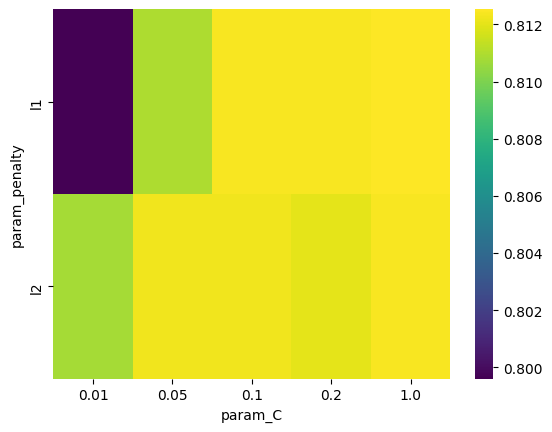

In [37]:
LR_models = pd.DataFrame(Grid_LR.cv_results_)
res = (LR_models.pivot(index = 'param_penalty', columns = 'param_C', values = 'mean_test_score'))
_ = sns.heatmap(res, cmap = 'viridis')

**(Advanced) Improve the performance**

In [38]:
# Stratefied CV & reproducibility
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
Grid_LR_2 = GridSearchCV(LogisticRegression(solver = 'liblinear'), parameters, cv = 5, n_jobs = -1, verbose = 1)

##### 2. KNN
- `n_neighbors`: number of neighbors to look at
- `metric` (default = 'minkowski')

In [39]:
# Possible hyperparameter options for KNN
parameters = {
    'n_neighbors': [1, 3, 5, 7, 9]
}
Grid_KNN = GridSearchCV(KNeighborsClassifier(), parameters, cv = 5)
Grid_KNN.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [1, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [40]:
# best parameters
print_grid_search_metrics(Grid_KNN)

Best score: 0.8433333333333334
Best parameters set:
n_neighbors:9


In [41]:
best_KNN_model = Grid_KNN.best_estimator_
best_KNN_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [42]:
best_KNN_model.score(X_test, y_test)

0.8428

##### 3. Random Forest
- `n_estimators`: number of decision trees in the forest
- `criterion`: 'gini' or 'entropy'
- `max_depth`: maximum depth of trees
- `max_feature`: number of features to consider at each split

In [43]:
parameters = {
    'n_estimators': [60, 80, 100],
    'max_depth': [1, 5, 10]
}
Grid_RF = GridSearchCV(RandomForestClassifier(), parameters, cv = 5)
Grid_RF.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [1, 5, ...], 'n_estimators': [60, 80, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [44]:
print_grid_search_metrics(Grid_RF)

Best score: 0.8667999999999999
Best parameters set:
max_depth:10
n_estimators:100


In [45]:
best_RF_model = Grid_RF.best_estimator_
best_RF_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [46]:
best_RF_model.score(X_test, y_test)

0.8612

#### Step 3.3. Model Evaluation - Confusion Matrix

- Positive denotes the class of interest: churn
- $Precision = \frac{tp}{tp + fp}$: Total number of true predicted churn divided by the total number of predicted churn
- $Recall = \frac{tp}{tp + fn}$: Total number of true predicted churn divided by the total number of true churn.
```
              Predicted
              0      1
True   0   [[TN,    FP],
       1    [FN,    TP]]
```

In [47]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score

# Calculate accuracy, precision and recall
def cal_evaluation(classifier, cm): #cm denotes confusion matrix
    tn = cm[0][0]
    fp = cm[0][1]
    fn = cm[1][0]
    tp = cm[1][1]
    accuracy = (tp + tn)/ (tn + fp + fn + tp)
    precision = tp/(tp + fp + 0.0)
    recall = tp/(tp + fn + 0.0)
    print(classifier)
    print("Accuracy is: " + str(accuracy))
    print("Precision is " + str(precision))
    print("Recall is: " + str(recall))
    print()

# Print out confusion matrices
def draw_confusion_matrices(confusion_matrices):
    class_name = ['Not', 'Churn'] # Not for class 0, and Churn for class 1
    for cm in confusion_matrices: # cm is just a loop variable across the list 'confusion_matrices'
        classifier, cm = cm[0], cm[1]
        cal_evaluation(classifier, cm)
    

In [48]:
# Create the list 'confusion_matrices'
confusion_matrices = [
    ('Random Forest', confusion_matrix(y_test, best_RF_model.predict(X_test))),
    ('LogisticRegression', confusion_matrix(y_test, best_LR_model.predict(X_test))),
    ('K Nearest Neighbors', confusion_matrix(y_test, best_KNN_model.predict(X_test)))
]

In [49]:
# print the evaluation results
draw_confusion_matrices(confusion_matrices)

Random Forest
Accuracy is: 0.8612
Precision is 0.81640625
Recall is: 0.4106090373280943

LogisticRegression
Accuracy is: 0.8092
Precision is 0.5963855421686747
Recall is: 0.1944990176817289

K Nearest Neighbors
Accuracy is: 0.8428
Precision is 0.7283464566929134
Recall is: 0.36345776031434185



#### Step 3.4. Model Evaluation - ROC & AUC
##### 1. ROC of Random Forest Model

In [50]:
from sklearn import metrics
from sklearn.metrics import roc_curve

In [51]:
# Use predict_prob to get the probability results of random forest
# https://github.com/scikit-learn/scikit-learn/blob/c60dae2060/sklearn/ensemble/_forest.py#L921
# The predicted class probabilities of an input sample are computed as the mean predicted class probabilities of the trees in the forest.
# it returns [[probability of class 0][probability of class 1]]
print(best_RF_model.predict_proba(X_test))
y_pred_rf = best_RF_model.predict_proba(X_test)[:, 1]
print(y_pred_rf)

[[0.70638617 0.29361383]
 [0.94127428 0.05872572]
 [0.75143772 0.24856228]
 ...
 [0.85079921 0.14920079]
 [0.93686322 0.06313678]
 [0.87713847 0.12286153]]
[0.29361383 0.05872572 0.24856228 ... 0.14920079 0.06313678 0.12286153]


In [52]:
# roc_curve() returns fpr, tpr, thresholds for different thresholds
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)

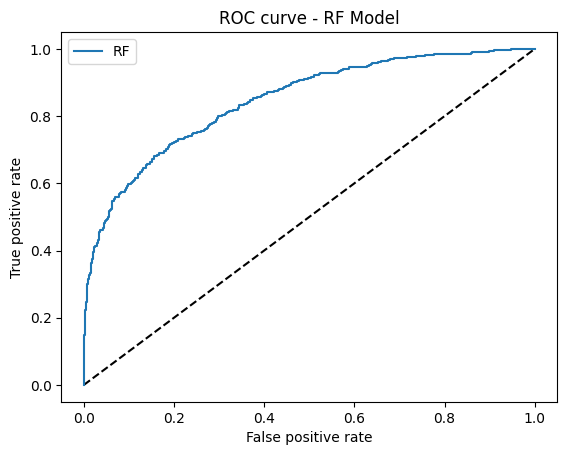

In [53]:
# Visualize ROC curve
import matplotlib.pyplot as plt
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - RF Model')
plt.legend(loc='best')
plt.show()

##### 2. ROC of Logistic Regression Model

In [54]:
y_pred_lr = best_LR_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
print(best_LR_model.predict_proba(X_test))
print(y_pred_lr)

[[0.82436919 0.17563081]
 [0.93171764 0.06828236]
 [0.85520613 0.14479387]
 ...
 [0.7145112  0.2854888 ]
 [0.89279058 0.10720942]
 [0.85560743 0.14439257]]
[0.17563081 0.06828236 0.14479387 ... 0.2854888  0.10720942 0.14439257]


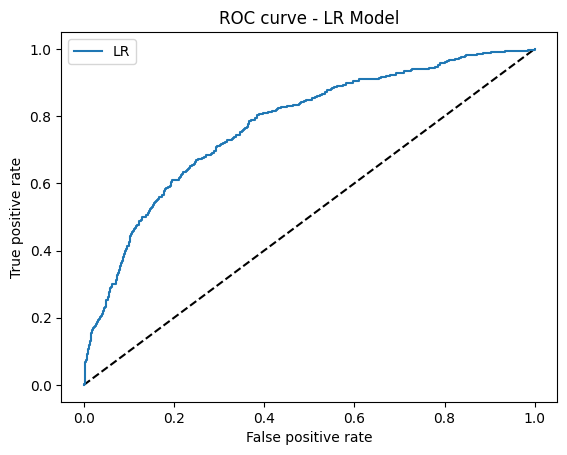

In [55]:
# Visualize ROC curve
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_lr, tpr_lr, label='LR')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - LR Model')
plt.legend(loc='best')
plt.show()

##### 3. ROC of KNN Model

In [56]:
y_pred_knn = best_KNN_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn)
print(best_KNN_model.predict_proba(X_test))
print(y_pred_knn)

[[1.         0.        ]
 [1.         0.        ]
 [0.88888889 0.11111111]
 ...
 [0.77777778 0.22222222]
 [1.         0.        ]
 [1.         0.        ]]
[0.         0.         0.11111111 ... 0.22222222 0.         0.        ]


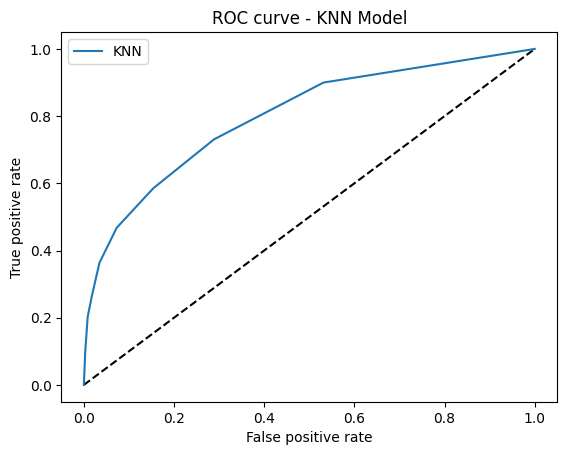

In [57]:
# Visualize ROC curve
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_knn, tpr_knn, label='KNN')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - KNN Model')
plt.legend(loc='best')
plt.show()

---
## Step 4 - Check Feature Importance/Contribution
#### Step 4.1. Logistic Regression Model

In [63]:
# Examine the contribution of the features of interest
X_with_corr = X.copy()
categories = ['Geography']
enc_ohe.fit(X_with_corr[categories])
X_with_corr = OneHotEncoding(X_with_corr, enc_ohe, ['Geography'])
X_with_corr['Gender'] = enc_oe.transform(X_with_corr[['Gender']])
X_with_corr['SalaryInRMB'] = X_with_corr['EstimatedSalary'] * 6.4
X_with_corr.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,SalaryInRMB
0,619,0.0,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0,648632.832
1,608,0.0,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0,720272.512
2,502,0.0,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0,729162.048
3,699,0.0,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0,600490.432
4,850,0.0,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0,506138.240


In [64]:
# Check the coef of a L2 logistic regression model and determine which features contribute more
np.random.seed()
scaler = StandardScaler()
X_l2 = scaler.fit_transform(X_with_corr)
LRmodel_l2 = LogisticRegression(penalty="l2", C = 0.1, solver='liblinear', random_state=42)
LRmodel_l2.fit(X_l2, y)
LRmodel_l2.coef_[0]

indices = np.argsort(abs(LRmodel_l2.coef_[0]))[::-1]

print ("Logistic Regression (L2) Coefficients")
for ind in range(X_with_corr.shape[1]):
  print ("{0} : {1}".format(X_with_corr.columns[indices[ind]],round(LRmodel_l2.coef_[0][indices[ind]], 4)))

Logistic Regression (L2) Coefficients
Age : 0.751
IsActiveMember : -0.5272
Gender : -0.2591
Geography_Germany : 0.2279
Balance : 0.162
Geography_France : -0.1207
Geography_Spain : -0.089
CreditScore : -0.0637
NumOfProducts : -0.0586
Tenure : -0.0452
HasCrCard : -0.0199
SalaryInRMB : 0.0137
EstimatedSalary : 0.0137


Findings:
- Age (0.751) → Strongest positive predictor. Older customers are more likely to churn.
- IsActiveMember (-0.5272) → Strong negative effect. Active members are less likely to churn.
- Gender (-0.2591) → Gender impacts churn, with this sign indicating the encoded gender is associated with lower likelihood of churn (depends on encoding scheme).
- Germany (0.2279) → Customers in Germany are more likely to churn.
- Key drivers: **Age, activity status, and geography** (Germany) are the dominant churn predictors.

#### Step 4.2. Random Forest Model - Feature Importance

In [65]:
X_RF = X.copy()

X_RF = OneHotEncoding(X_RF, enc_ohe, ['Geography'])
X_RF['Gender'] = enc_oe.transform(X_RF[['Gender']])

X_RF.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0.0,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0
1,608,0.0,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0
2,502,0.0,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0
3,699,0.0,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0
4,850,0.0,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0


In [66]:
# check feature importance of random forest for feature selection
forest = RandomForestClassifier()
forest.fit(X_RF, y)

importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature importance ranking by Random Forest Model:")
for ind in range(X.shape[1]):
  print ("{0} : {1}".format(X_RF.columns[indices[ind]],round(importances[indices[ind]], 4)))

Feature importance ranking by Random Forest Model:
Age : 0.2385
EstimatedSalary : 0.1458
CreditScore : 0.1444
Balance : 0.1414
NumOfProducts : 0.1289
Tenure : 0.0832
IsActiveMember : 0.0403
Geography_Germany : 0.0218
Gender : 0.0184
HasCrCard : 0.0184


# Summary